In [1]:
### 1 Setup & Data Loading

In [2]:
!pip install kagglehub
import kagglehub

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Download latest version
path = kagglehub.dataset_download("abdullah0a/telecom-customer-churn-insights-for-analysis")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\User\.cache\kagglehub\datasets\abdullah0a\telecom-customer-churn-insights-for-analysis\versions\1


In [3]:
# Load the first file in the dataset folder
file_path = os.path.join(path, os.listdir(path)[0])
df = pd.read_csv(file_path)

df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,NaN,2208.32,No,Yes


In [4]:
### 2 Exploratory Data Analysis & Preprocessing

In [5]:
# Missing values and corrections;  
df.isnull().sum()

CustomerID           0
Age                  0
Gender               0
Tenure               0
MonthlyCharges       0
ContractType         0
InternetService    297
TotalCharges         0
TechSupport          0
Churn                0
dtype: int64

In [6]:
df["InternetService"] = df["InternetService"].fillna("")
df.isnull().sum()

CustomerID         0
Age                0
Gender             0
Tenure             0
MonthlyCharges     0
ContractType       0
InternetService    0
TotalCharges       0
TechSupport        0
Churn              0
dtype: int64

In [7]:
# duplicate check 
df.duplicated().sum()

np.int64(0)

In [8]:
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,,2208.32,No,Yes


In [9]:
#convert churn to binary

df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# Verify the changes
df["Churn"].value_counts()

Churn
1    883
0    117
Name: count, dtype: int64

In [10]:
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,1
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,1
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,1
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,1
4,5,42,Male,32,69.01,Month-to-Month,,2208.32,No,1


In [11]:
#remove unique identifiers
df.drop(columns=["CustomerID"], inplace=True)

In [12]:
df.head()

,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,1
1,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,1
2,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,1
3,60,Female,8,102.34,One-Year,DSL,818.72,Yes,1
4,42,Male,32,69.01,Month-to-Month,,2208.32,No,1


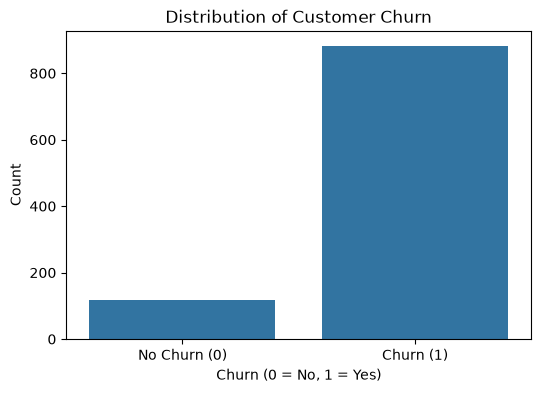

In [13]:
#bar chart visualization of churn vs no churn comparison 
plt.figure(figsize=(6, 4))
sns.countplot(x="Churn", data=df)
plt.title("Distribution of Customer Churn")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.xticks(ticks=[0, 1], labels=["No Churn (0)", "Churn (1)"])
plt.show()

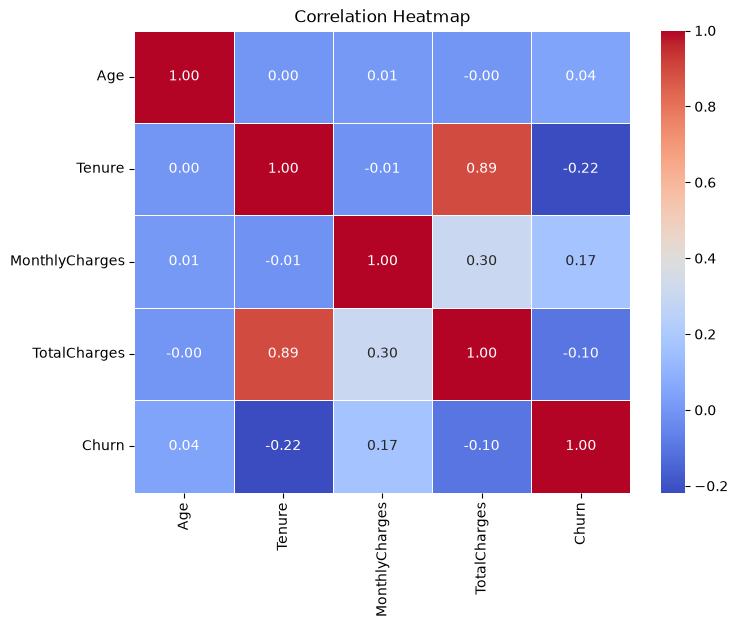

In [17]:
#correlation heat map- for numeric values 

corr = df.select_dtypes(include=["number"]).corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [15]:
### 3 Model Training & Evaluation

In [20]:
df.columns

Index(['Age', 'Gender', 'Tenure', 'MonthlyCharges', 'ContractType',
       'InternetService', 'TotalCharges', 'TechSupport', 'Churn'],
      dtype='str')

In [28]:
Y = df[["Churn"]]
X = df[["Age","Gender","Tenure","MonthlyCharges"]]

In [29]:
X

,Age,Gender,Tenure,MonthlyCharges
0,49,Male,4,88.35
1,43,Male,0,36.67
2,51,Female,2,63.79
3,60,Female,8,102.34
4,42,Male,32,69.01
...,...,...,...,...
995,42,Male,41,37.14
996,62,Male,9,80.93
997,51,Female,15,111.72
998,39,Male,68,65.67


In [30]:
Y


,Churn
0,1
1,1
2,1
3,1
4,1
...,...
995,1
996,1
997,1
998,1


In [33]:
#Gender : 1 is female, 0 is male 

X["Gender"] = x["Gender"].apply(lambda x: 1 if x == "Female" else 0)

X.head()

,Age,Gender,Tenure,MonthlyCharges
0,49,0,4,88.35
1,43,0,0,36.67
2,51,1,2,63.79
3,60,1,8,102.34
4,42,0,32,69.01


In [35]:
# Split data (80% train, 20% test)

from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)

# Print shapes to verify
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (800, 4)
X_test shape: (200, 4)
y_train shape: (800, 1)
y_test shape: (200, 1)


In [38]:
#scaling X values, import scaler out( as scaler.pkl)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

In [39]:
import joblib

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [40]:
X_test = scaler.fit_transform(X_test)

In [42]:
X_test

AttributeError: 'numpy.ndarray' object has no attribute 'head'

In [52]:
#import model

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize and fit the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train.values.ravel())

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [53]:
# Make predictions on the test set
rf_preds = rf_model.predict(X_test)

In [54]:
# Evaluate performance
print("Random Forest Accuracy:", accuracy_score(y_test, rf_preds))
print("\nClassification Report:\n", classification_report(y_test, rf_preds))

Random Forest Accuracy: 0.9

Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.26      0.38        23
           1       0.91      0.98      0.95       177

    accuracy                           0.90       200
   macro avg       0.79      0.62      0.66       200
weighted avg       0.88      0.90      0.88       200



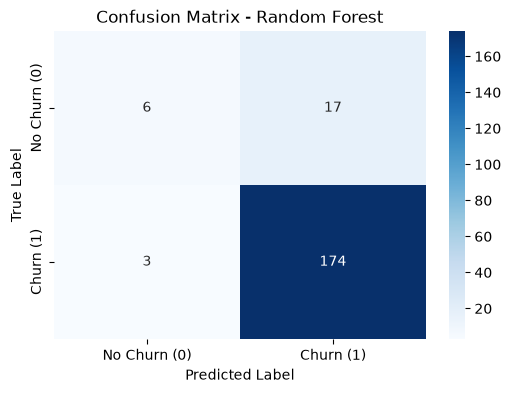

In [56]:
# Plot confusion matrix 
cm = confusion_matrix(y_test, rf_preds)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn (0)", "Churn (1)"],
    yticklabels=["No Churn (0)", "Churn (1)"],
)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

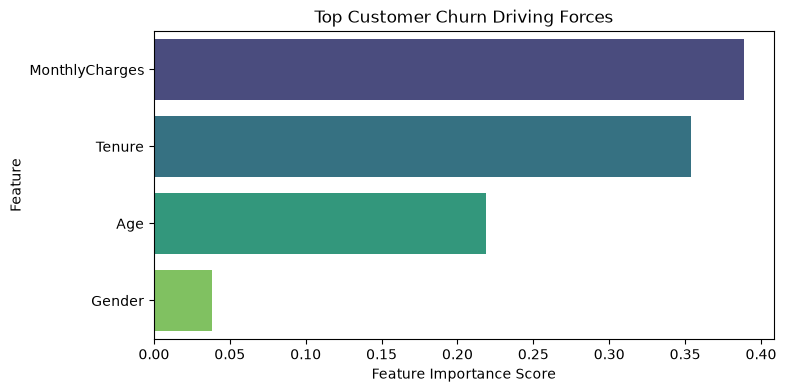

In [57]:
# Top 5 customer churn driving forces


importances = rf_model.feature_importances_
feature_names = X.columns

# DataFrame for ranking
feature_importance_df = (
    pd.DataFrame({"Feature": feature_names, "Importance": importances})
    .sort_values(by="Importance", ascending=False)
    .head(5)
)

# Plot 
plt.figure(figsize=(8, 4))
sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance_df,
    palette="viridis",
    hue="Feature",
    legend=False,
)
plt.title("Top Customer Churn Driving Forces")
plt.xlabel("Feature Importance Score")
plt.ylabel("Feature")
plt.show()

In [58]:
# Save the trained Random Forest model
joblib.dump(rf_model, "rf_model.pkl")

['rf_model.pkl']

In [16]:
### 4 Deployment as a Streamlit Web App